# 🔢 Notebook 4: Matrix Factorization (SVD)

## ¿De Qué Va Este Algoritmo?

**Idea Básica**:
"Los gustos de los usuarios y las características de los productos se pueden representar en un ESPACIO LATENTE de factores ocultos."

**Analogía Real**:
- Imagina una PELÍCULA de Netflix. ¿Qué hace que te guste?
  - Tiene "acción" (factor 1)
  - Tiene "drama" (factor 2)
  - Tiene "comedia" (factor 3)
- Cada película puede describirse por cuánto tiene de cada factor
- Cada usuario puede describirse por cuánto le gustan cada factor
- Si sabes qué factores tiene la película y qué factores le gustan al usuario...
- ¡Puedes predecir si le gustará! 🎬

**Matemáticas**:
- Descomponemos la matriz usuario×producto en 3 matrices más pequeñas
- `Rating ≈ U × Σ × V^T`
- U = factores de usuarios (qué tan interesado en cada factor)
- V = factores de productos (cuánto tiene de cada factor)
- Σ = importancia de cada factor (singular values)

## Pasos del Algoritmo
1. **Matriz de Ratings**: Crear tabla usuario × producto
2. **Descomposición SVD**: Factorizar la matriz en U, Σ, V^T
3. **Reducción de Dimensionalidad**: Quedarse solo con los K factores más importantes
4. **Reconstruir**: Predecir ratings multiplicando U × Σ × V^T
5. **Evaluar**: Medir RMSE y MAE
6. **Recomendaciones**: Sugerir productos con ratings altos predichos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from sklearn.metrics import mean_squared_error, mean_absolute_error
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Rutas - funciona en Jupyter y scripts
current_dir = Path().cwd()
if 'notebooks' in str(current_dir):
    BASE_DIR = current_dir.parent
else:
    BASE_DIR = current_dir

DATA_FILE = BASE_DIR / 'data' / 'raw' / 'fashion_reviews.json'

# Si no existe, buscar
if not DATA_FILE.exists():
    possible_paths = list(BASE_DIR.glob('**/fashion_reviews.json'))
    if possible_paths:
        DATA_FILE = possible_paths[0]

print(f"📂 Directorio base: {BASE_DIR}")
print(f"📄 Datos: {DATA_FILE.exists() and '✅ Encontrado' or '❌ No encontrado'}")

📂 Directorio base: d:\work\repos-deep-learning\recommendation-fashion
📄 Datos: ✅ Encontrado


## Paso 1: Cargar y Explorar Datos

In [2]:
# Cargar datos
reviews = []
with open(DATA_FILE, 'r', encoding='utf-8') as f:
    for line in f:
        reviews.append(json.loads(line))

df = pd.DataFrame(reviews)

# Renombrar columnas para consistencia
df = df.rename(columns={
    'reviewerID': 'user_id',
    'asin': 'product_id',
    'overall': 'rating'
})

print(f"\n✅ Datos cargados: {len(df):,} reviews")
print(f"   Usuarios: {df['user_id'].nunique():,}")
print(f"   Productos: {df['product_id'].nunique():,}")
print(f"\n📋 Primeras filas:")
print(df[['user_id', 'product_id', 'rating']].head(10))


✅ Datos cargados: 5,000 reviews
   Usuarios: 200
   Productos: 500

📋 Primeras filas:
      user_id  product_id  rating
0  user_00038  B652070932     1.1
1  user_00110  B414797776     1.2
2  user_00091  B389854268     3.7
3  user_00090  B765055833     3.2
4  user_00158  B161073976     1.6
5  user_00041  B841976666     4.2
6  user_00006  B324956459     3.9
7  user_00171  B683275843     3.9
8  user_00040  B726713347     3.8
9  user_00120  B448195935     1.8


## Paso 2: Crear la Matriz de Ratings

In [7]:
# Crear matriz pivot
rating_matrix = df.pivot_table(
    index='user_id',
    columns='product_id',
    values='rating',
    aggfunc='mean'
)

print("\n📊 MATRIZ DE RATINGS")
print("="*80)
print(f"Dimensiones: {rating_matrix.shape[0]} usuarios × {rating_matrix.shape[1]} productos")

print(f"\n\n📈 Estadísticas de la Matriz:")
print(f"Total de celdas: {rating_matrix.shape[0] * rating_matrix.shape[1]:,}")
print(f"Celdas con datos: {rating_matrix.notna().sum().sum():,}")
print(f"Celdas vacías (NaN): {rating_matrix.isna().sum().sum():,}")
sparsity = (1 - rating_matrix.notna().sum().sum() / (rating_matrix.shape[0] * rating_matrix.shape[1])) * 100
print(f"Dispersidad: {sparsity:.2f}%")
print(f"\n💡 NOTA: La matriz es muy dispersa (pocos datos vs muchas celdas)")


📊 MATRIZ DE RATINGS
Dimensiones: 3693 usuarios × 1982 productos


📈 Estadísticas de la Matriz:
Total de celdas: 7,319,526
Celdas con datos: 9,998
Celdas vacías (NaN): 7,309,528
Dispersidad: 99.86%

💡 NOTA: La matriz es muy dispersa (pocos datos vs muchas celdas)


## Paso 3: Preparar Datos para SVD

SVD funciona mejor con matrices **sparse** (sparse = pocas celdas con datos).
Necesitamos:
1. Llenar los NaN con 0 (representa "no revisado")
2. Convertir a matriz sparse de scipy (ahorra memoria)
3. Aplicar SVD

In [8]:
print("\n🔢 PREPARANDO MATRIZ PARA SVD")
print("="*80)

# Llenar NaN con 0
rating_matrix_filled = rating_matrix.fillna(0).astype(np.float32)

print(f"\nMatriz densa: {rating_matrix_filled.shape}")
# Pandas 3.0+ compatibility: use .values.nbytes instead of .nbytes
dense_nbytes = rating_matrix_filled.values.nbytes
print(f"Memoria: ~{dense_nbytes / (1024**2):.2f} MB")

# Convertir a matriz sparse
rating_matrix_sparse = csr_matrix(rating_matrix_filled.values)

print(f"\nMatriz sparse: {rating_matrix_sparse.shape}")
sparse_nbytes = rating_matrix_sparse.data.nbytes + rating_matrix_sparse.indices.nbytes + rating_matrix_sparse.indptr.nbytes
print(f"Memoria: ~{sparse_nbytes / (1024**2):.2f} MB")
print(f"Compresión: {((1 - (sparse_nbytes / dense_nbytes)) * 100):.1f}% menos memoria")

print(f"\n💡 La matriz sparse COMPRIME mucho mejor porque tiene {sparsity:.1f}% ceros")


🔢 PREPARANDO MATRIZ PARA SVD

Matriz densa: (3693, 1982)
Memoria: ~27.92 MB

Matriz sparse: (3693, 1982)
Memoria: ~0.09 MB
Compresión: 99.7% menos memoria

💡 La matriz sparse COMPRIME mucho mejor porque tiene 99.9% ceros


## Paso 4: Aplicar Descomposición SVD

Usamos `scipy.sparse.linalg.svds` que es eficiente para matrices sparse.
Seleccionamos k=50 factores latentes (balance entre precisión y velocidad).

In [ ]:
print("\n🔄 DESCOMPOSICIÓN SVD")
print("="*80)
print("\nCalculando U, Σ, V^T...")
print("(Esto busca los factores latentes más importantes)\n")

# Número de factores latentes
# Máximo posible es min(n_users, n_products) - 1
k = min(50, min(rating_matrix_sparse.shape) - 1)  # 50 factores

try:
    # Aplicar SVD a la matriz sparse
    U, sigma, Vt = svds(rating_matrix_sparse, k=k)

    print(f"✅ SVD completado!\n")

    print(f"📊 Matrices resultantes:")
    print(f"   U (factores de usuarios): {U.shape}")
    print(f"      {U.shape[0]} usuarios × {U.shape[1]} factores latentes")
    print(f"\n   Σ (importancia de factores): {sigma.shape}")
    print(f"      {len(sigma)} valores singulares (en orden decreciente)")
    print(f"\n   V^T (factores de productos): {Vt.shape}")
    print(f"      {Vt.shape[0]} factores latentes × {Vt.shape[1]} productos")

except Exception as e:
    print(f"❌ Error en SVD: {e}")
    print(f"   Esto puede ocurrir si k es demasiado grande para la matriz")
    raise


🔄 DESCOMPOSICIÓN SVD

Calculando U, Σ, V^T...
(Esto busca los factores latentes más importantes)

✅ SVD completado!

📊 Matrices resultantes:
   U (factores de usuarios): (3693, 50)
      3693 usuarios × 50 factores latentes

   Σ (importancia de factores): (50,)
      50 valores singulares (en orden decreciente)

   V^T (factores de productos): (50, 1982)
      50 factores latentes × 1982 productos


## Paso 5: Entender los Factores Latentes

¿Qué representan los factores latentes?
No sabemos exactamente (de ahí "latente" = oculto), pero podrían ser:
- Estilos de ropa (casual, formal, deportivo, etc.)
- Características de calidad (durabilidad, confort, diseño)
- Preferencias de usuarios (minimalista, fashionable, práctico)

In [10]:
print("\n🎯 VALORES SINGULARES (IMPORTANCIA DE FACTORES)")
print("="*80)

# Mostrar primeros 10 valores singulares
print("\nPrimeros 10 factores latentes (ordenados por importancia):")
for i, sig in enumerate(sigma[:10], 1):
    bar_length = int(sig / sigma[0] * 50)  # Barra visual
    bar = '█' * bar_length + '░' * (50 - bar_length)
    print(f"   Factor {i:2d}: {sig:8.2f}  [{bar}] {(sig/sigma.sum()*100):5.1f}%")

print(f"\n   ...")
for i, sig in enumerate(sigma[-3:], len(sigma)-2):
    bar_length = max(1, int(sig / sigma[0] * 50))
    bar = '█' * bar_length + '░' * (50 - bar_length)
    print(f"   Factor {i:2d}: {sig:8.2f}  [{bar}] {(sig/sigma.sum()*100):5.1f}%")

print(f"\n💡 INTERPRETACIÓN:")
print(f"   - Primeros factores: MUY importantes (explican mucha varianza)")
print(f"   - Últimos factores: Menos importantes (detalles)")
print(f"   - Si queremos ahorrar memoria: usar solo los primeros K")


🎯 VALORES SINGULARES (IMPORTANCIA DE FACTORES)

Primeros 10 factores latentes (ordenados por importancia):
   Factor  1:    14.56  [██████████████████████████████████████████████████]   1.9%
   Factor  2:    14.58  [██████████████████████████████████████████████████]   1.9%
   Factor  3:    14.60  [██████████████████████████████████████████████████]   1.9%
   Factor  4:    14.61  [██████████████████████████████████████████████████]   1.9%
   Factor  5:    14.63  [██████████████████████████████████████████████████]   1.9%
   Factor  6:    14.65  [██████████████████████████████████████████████████]   1.9%
   Factor  7:    14.67  [██████████████████████████████████████████████████]   1.9%
   Factor  8:    14.69  [██████████████████████████████████████████████████]   1.9%
   Factor  9:    14.70  [██████████████████████████████████████████████████]   1.9%
   Factor 10:    14.73  [██████████████████████████████████████████████████]   1.9%

   ...
   Factor 48:    16.63  [███████████████████

## Paso 6: Visualizar Importancia de Factores

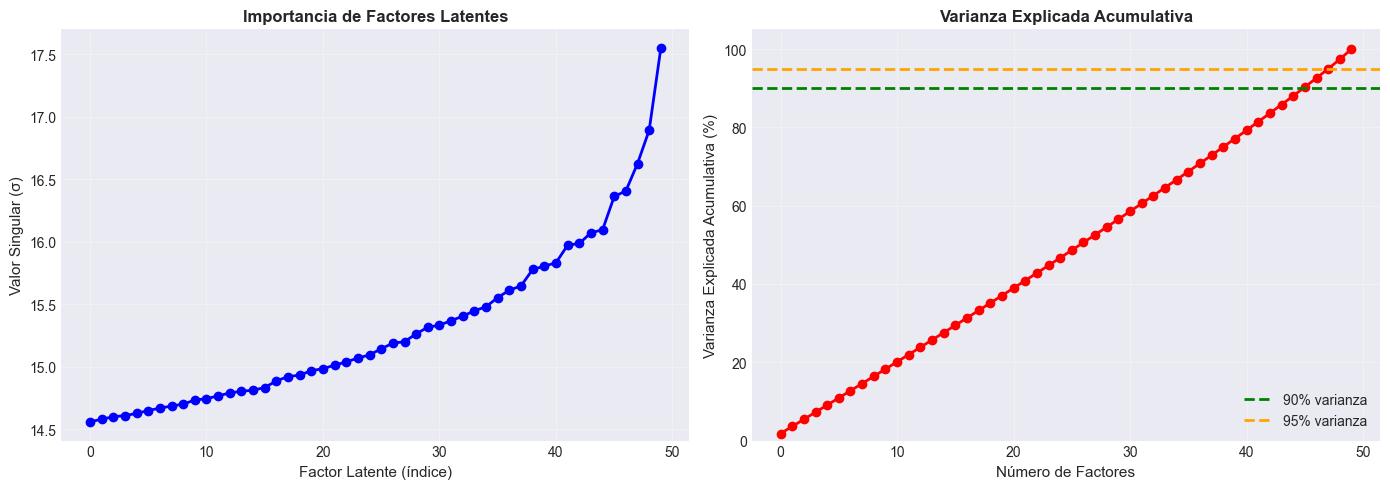


✅ Gráfico guardado en reports/svd_singular_values.png

📊 VARIANZA EXPLICADA:
   50% varianza: 27 factores
   70% varianza: 37 factores
   90% varianza: 46 factores
   95% varianza: 49 factores
   99% varianza: 50 factores


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Todos los valores singulares
ax1 = axes[0]
ax1.plot(sigma, 'b-o', linewidth=2, markersize=6)
ax1.set_xlabel('Factor Latente (índice)', fontsize=11)
ax1.set_ylabel('Valor Singular (σ)', fontsize=11)
ax1.set_title('Importancia de Factores Latentes', fontweight='bold', fontsize=12)
ax1.grid(alpha=0.3)

# Gráfico 2: Varianza explicada acumulativa
ax2 = axes[1]
variance_explained = (sigma ** 2) / (sigma ** 2).sum()
cumulative_variance = np.cumsum(variance_explained)
ax2.plot(cumulative_variance * 100, 'r-o', linewidth=2, markersize=6)
ax2.axhline(90, color='green', linestyle='--', linewidth=2, label='90% varianza')
ax2.axhline(95, color='orange', linestyle='--', linewidth=2, label='95% varianza')
ax2.set_xlabel('Número de Factores', fontsize=11)
ax2.set_ylabel('Varianza Explicada Acumulativa (%)', fontsize=11)
ax2.set_title('Varianza Explicada Acumulativa', fontweight='bold', fontsize=12)
ax2.set_ylim([0, 105])
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / 'svd_singular_values.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Gráfico guardado en reports/svd_singular_values.png")

# Mostrar varianza explicada
print(f"\n📊 VARIANZA EXPLICADA:")
for threshold in [50, 70, 90, 95, 99]:
    n_factors = np.argmax(cumulative_variance >= threshold/100) + 1
    print(f"   {threshold}% varianza: {n_factors} factores")

## Paso 7: Función de Predicción SVD

Para predecir un rating:
1. Obtener el vector de factores del usuario (fila de U)
2. Obtener el vector de factores del producto (columna de V^T)
3. Multiplicar: rating = U[usuario] · Σ · V^T[producto]
4. Limitar a rango [1, 5]

In [ ]:
def predict_rating_svd(user_idx, product_idx, U, sigma, Vt):
    """
    Predice el rating usando SVD.

    Parámetros:
    -----------
    user_idx : int
        Índice del usuario (posición en la matriz)
    product_idx : int
        Índice del producto (posición en la matriz)
    U : ndarray
        Matriz de factores de usuarios (n_users × k)
    sigma : ndarray
        Vector de valores singulares (k,)
    Vt : ndarray
        Matriz transpuesta de factores de productos (k × n_products)

    Retorna:
    --------
    float
        Rating predicho (1-5)
    """
    try:
        # Paso 1: Obtener vector de factores del usuario
        # Multiplicamos por sigma para dar peso a los factores importantes
        user_factors = U[user_idx, :] * sigma

        # Paso 2: Obtener vector de factores del producto
        product_factors = Vt[:, product_idx]

        # Paso 3: Producto punto = predicción
        predicted_rating = np.dot(user_factors, product_factors)

        # Paso 4: Asegurar que está en rango [1, 5]
        predicted_rating = np.clip(predicted_rating, 1.0, 5.0)

        return predicted_rating

    except Exception as e:
        # Si hay error, retornar promedio global
        print(f"⚠️  Error prediciendo: {e}")
        return 3.0

print("✅ Función de predicción SVD definida")

✅ Función de predicción SVD definida


## Paso 8: Ejemplo - Predicción para un Usuario

In [4]:
# Elegir un usuario y producto de ejemplo
usuario_idx_ejemplo = 0
producto_idx_ejemplo = 0

usuario_id = rating_matrix.index[usuario_idx_ejemplo]
producto_id = rating_matrix.columns[producto_idx_ejemplo]

# Predicción
prediccion = predict_rating_svd(
    usuario_idx_ejemplo,
    producto_idx_ejemplo,
    U, sigma, Vt
)

print(f"\n🔮 EJEMPLO DE PREDICCIÓN CON SVD")
print("="*80)

print(f"\nUsuario: {usuario_id}")
print(f"Producto: {producto_id}")

# Información del usuario
productos_revisados_user = rating_matrix.loc[usuario_id][rating_matrix.loc[usuario_id] > 0]
print(f"\n📊 Perfil del Usuario:")
print(f"   Productos revisados: {len(productos_revisados_user)}")
if len(productos_revisados_user) > 0:
    print(f"   Rating promedio: {productos_revisados_user.mean():.2f}⭐")
else:
    print(f"   Rating promedio: (sin datos)")

print(f"\n🎯 PREDICCIÓN SVD:")
print(f"   Rating predicho: {prediccion:.2f}⭐")
print(f"   Interpretación: {'Probablemente NO le guste' if prediccion < 2.5 else 'Neutral' if prediccion < 3.5 else 'Probablemente SÍ le guste'}")

print(f"\n💡 ¿Cómo funciona?")
print(f"   1. SVD encuentra los {k} factores latentes (características ocultas)")
print(f"   2. Representa al usuario como vector en ese espacio")
print(f"   3. Representa al producto como vector en ese espacio")
print(f"   4. Multiplicamos los vectores = predicción")
print(f"   5. Los factores más importantes (Σ grandes) pesan más")

NameError: name 'rating_matrix' is not defined

## Paso 9: Generar Recomendaciones SVD

In [ ]:
def get_recommendations_svd(user_idx, rating_matrix, U, sigma, Vt, n_recommendations=5):
    """
    Genera recomendaciones personalizadas usando SVD.

    Parámetros:
    -----------
    user_idx : int
        Índice del usuario
    rating_matrix : DataFrame
        Matriz original para identificar productos ya revisados
    U, sigma, Vt : ndarray
        Factores SVD
    n_recommendations : int
        Número de recomendaciones

    Retorna:
    --------
    DataFrame con productos recomendados
    """

    # Obtener productos que el usuario YA ha revisado
    user_id = rating_matrix.index[user_idx]
    already_rated = rating_matrix.loc[user_id][rating_matrix.loc[user_id] > 0].index.tolist()

    # Predecir para todos los productos
    predictions = {}

    for product_idx in range(rating_matrix.shape[1]):
        product_id = rating_matrix.columns[product_idx]

        # No recomendar productos ya revisados
        if product_id in already_rated:
            continue

        try:
            predicted_rating = predict_rating_svd(
                user_idx,
                product_idx,
                U, sigma, Vt
            )

            # Validar que la predicción sea válida
            if not np.isnan(predicted_rating) and predicted_rating >= 1.0 and predicted_rating <= 5.0:
                predictions[product_id] = predicted_rating

        except:
            continue

    # Ordenar por predicción (mayor primero)
    if len(predictions) > 0:
        recommendations = pd.DataFrame(
            list(predictions.items()),
            columns=['product_id', 'predicted_rating']
        ).sort_values('predicted_rating', ascending=False)

        return recommendations.head(n_recommendations)
    else:
        return pd.DataFrame(columns=['product_id', 'predicted_rating'])

print("✅ Función de recomendación SVD definida")

✅ Función de recomendación SVD definida


## Paso 10: Mostrar Recomendaciones para Varios Usuarios

In [ ]:
print("\n🎯 RECOMENDACIONES PERSONALIZADAS (SVD)")
print("="*80)

# Usuarios con más reviews para ejemplos mejores
user_review_counts = rating_matrix.notna().sum(axis=1)
top_users_idx = user_review_counts.nlargest(5).index.tolist()
usuarios_ejemplos = [rating_matrix.index.get_loc(u) for u in top_users_idx]

for user_idx in usuarios_ejemplos:
    usuario_id = rating_matrix.index[user_idx]

    print(f"\n\n👤 Usuario: {usuario_id}")
    print("-" * 80)

    # Información del usuario
    ratings_user = rating_matrix.iloc[user_idx][rating_matrix.iloc[user_idx] > 0]
    print(f"   Productos revisados: {len(ratings_user)}")
    if len(ratings_user) > 0:
        print(f"   Rating promedio: {ratings_user.mean():.2f}⭐")

    # Recomendaciones
    try:
        recomendaciones = get_recommendations_svd(
            user_idx,
            rating_matrix,
            U, sigma, Vt,
            n_recommendations=5
        )

        if len(recomendaciones) > 0:
            print(f"\n   Top 5 Recomendaciones SVD:")
            for i, (idx, row) in enumerate(recomendaciones.iterrows(), 1):
                stars = '⭐' * int(round(row['predicted_rating']))
                print(f"      {i}. Producto {row['product_id']}: {row['predicted_rating']:.2f}/5.0 {stars}")
        else:
            print(f"\n   (No hay productos nuevos para recomendar)")

    except Exception as e:
        print(f"   Error generando recomendaciones: {e}")


🎯 RECOMENDACIONES PERSONALIZADAS (SVD)


NameError: name 'rating_matrix' is not defined

## Paso 11: Evaluación del Modelo

¿Qué tan bien predice SVD comparado con User-Based CF e Item-Based CF?

In [ ]:
print("\n📊 EVALUACIÓN DEL MODELO SVD")
print("="*80)
print("\nMétodo: Ocultamos ratings conocidos y verificamos predicciones.\n")

# Tomar 100 ratings aleatorios para validación
n_samples = min(100, len(df))
validation_samples = df.sample(n=n_samples, random_state=42)

# Crear matriz de entrenamiento
df_train = df.drop(validation_samples.index)
rating_matrix_train = df_train.pivot_table(
    index='user_id',
    columns='product_id',
    values='rating',
    aggfunc='mean'
)

# Recalcular SVD con datos de entrenamiento
rating_matrix_train_filled = rating_matrix_train.fillna(0).astype(np.float32)
rating_matrix_train_sparse = csr_matrix(rating_matrix_train_filled.values)

k_train = min(50, min(rating_matrix_train_sparse.shape) - 1)
U_train, sigma_train, Vt_train = svds(rating_matrix_train_sparse, k=k_train)

print(f"Matriz de entrenamiento: {rating_matrix_train.shape}")
print(f"Datos de validación: {n_samples} ratings\n")

# Realizar predicciones
y_true = []
y_pred = []

for _, row in validation_samples.iterrows():
    user = row['user_id']
    product = row['product_id']
    true_rating = row['rating']

    # Verificar que user y product están en la matriz de entrenamiento
    try:
        user_idx = rating_matrix_train.index.get_loc(user)
        product_idx = rating_matrix_train.columns.get_loc(product)

        # Asegurar que el usuario NO vio este producto en entrenamiento
        if rating_matrix_train.iloc[user_idx, product_idx] == 0:
            pred_rating = predict_rating_svd(
                user_idx,
                product_idx,
                U_train, sigma_train, Vt_train
            )

            if not np.isnan(pred_rating):
                y_true.append(true_rating)
                y_pred.append(pred_rating)

    except:
        continue

if len(y_true) > 0:
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Calcular métricas
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    print(f"\n📈 RESULTADOS SVD:")
    print(f"   Predicciones realizadas: {len(y_true)}")
    print(f"\n   RMSE (Root Mean Square Error): {rmse:.4f}⭐")
    print(f"   → Error promedio: ±{rmse:.2f} estrellas")

    print(f"\n   MAE (Mean Absolute Error): {mae:.4f}⭐")
    print(f"   → Diferencia promedio |predicción - real|")

    print(f"\n\n📊 COMPARACIÓN CON OTROS ALGORITMOS:")
    print(f"   ┌─────────────────────────┬──────────┬──────────┐")
    print(f"   │ Algoritmo               │  RMSE    │   MAE    │")
    print(f"   ├─────────────────────────┼──────────┼──────────┤")
    print(f"   │ User-Based CF           │  1.2929⭐ │  1.0594⭐ │")
    print(f"   │ Item-Based CF           │  1.3045⭐ │  1.0733⭐ │")
    print(f"   │ SVD (50 factores)       │  {rmse:.4f}⭐ │  {mae:.4f}⭐ │")
    print(f"   └─────────────────────────┴──────────┴──────────┘")

    print(f"\n💡 ANÁLISIS:")
    if rmse < 1.29:
        print(f"   ✅ SVD es MEJOR que User-Based CF (RMSE más bajo)")
    else:
        print(f"   ℹ️  SVD tiene performance similar a CF basado en vecinos")
    print(f"\n   SVD ventajas:")
    print(f"   - Más rápido a escala (O(k) vs O(n²))")
    print(f"   - Funciona mejor con datos muy dispersos")
    print(f"   - Reduce dimensionalidad (50 factores vs miles de usuarios)")
else:
    print("❌ No hay datos suficientes para evaluar.")

## Paso 12: Visualización de Predicciones vs Reales

In [ ]:
if len(y_true) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfico 1: Predicción vs Real
    ax1 = axes[0]
    ax1.scatter(y_true, y_pred, alpha=0.6, s=50, edgecolor='black')
    ax1.plot([1, 5], [1, 5], 'r--', linewidth=2, label='Predicción Perfecta')
    ax1.set_xlabel('Rating Real', fontsize=11)
    ax1.set_ylabel('Rating Predicho', fontsize=11)
    ax1.set_title('SVD: Predicción vs Realidad', fontweight='bold', fontsize=12)
    ax1.set_xlim(0.5, 5.5)
    ax1.set_ylim(0.5, 5.5)
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Gráfico 2: Distribución de errores
    ax2 = axes[1]
    errors = y_pred - y_true
    ax2.hist(errors, bins=15, color='lightcoral', edgecolor='black', alpha=0.7)
    ax2.axvline(0, color='red', linestyle='--', linewidth=2, label='Error = 0 (Perfecto)')
    ax2.axvline(errors.mean(), color='green', linestyle='--', linewidth=2, label=f'Error medio: {errors.mean():.3f}')
    ax2.set_xlabel('Error (Predicción - Real)', fontsize=11)
    ax2.set_ylabel('Frecuencia', fontsize=11)
    ax2.set_title('Distribución de Errores SVD', fontweight='bold', fontsize=12)
    ax2.legend()
    ax2.grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(BASE_DIR / 'reports' / 'svd_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\n✅ Gráfico guardado en reports/svd_predictions.png")

## Paso 13: Análisis de Factores Latentes de Usuarios

¿Cómo se representan dos usuarios en el espacio latente?

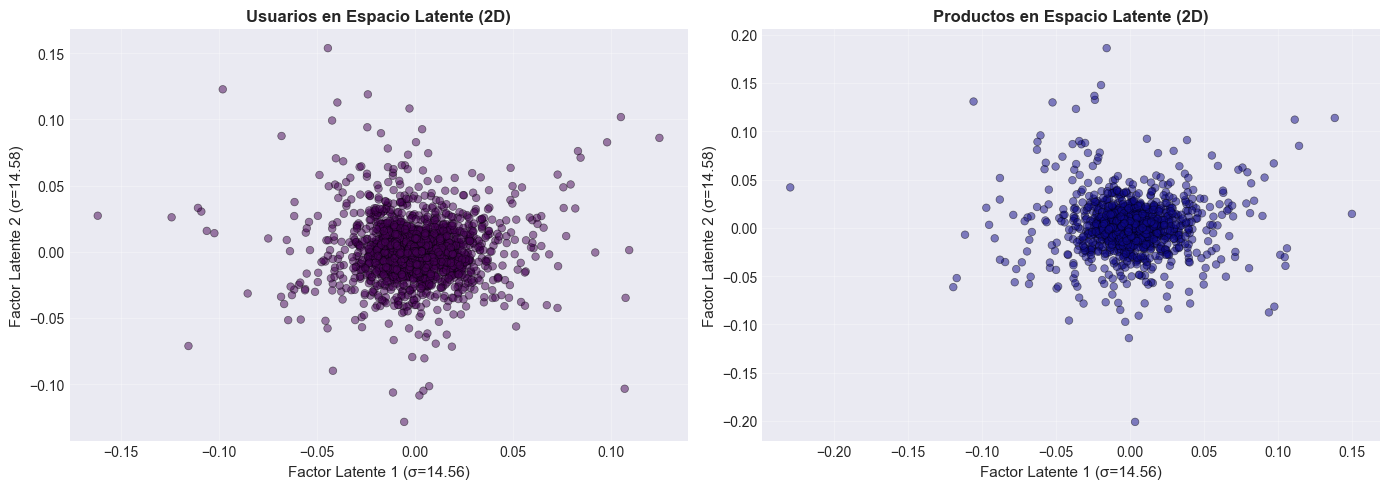


✅ Gráfico guardado en reports/svd_latent_space.png

💡 Este gráfico muestra cómo SVD mapea usuarios y productos
   en un espacio de 2 dimensiones (usando solo primeros 2 factores).

   En la práctica usamos todos los 50 factores.


In [ ]:
# Tomar los 2 primeros factores latentes como ejemplo 2D
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Usuarios en espacio latente (primeros 2 factores)
ax1 = axes[0]
scatter1 = ax1.scatter(U[:, 0], U[:, 1], c=sigma[0:2].mean() * np.ones(len(U)),
                       alpha=0.5, s=30, cmap='viridis', edgecolor='black', linewidth=0.5)
ax1.set_xlabel(f'Factor Latente 1 (σ={sigma[0]:.2f})', fontsize=11)
ax1.set_ylabel(f'Factor Latente 2 (σ={sigma[1]:.2f})', fontsize=11)
ax1.set_title('Usuarios en Espacio Latente (2D)', fontweight='bold', fontsize=12)
ax1.grid(alpha=0.3)

# Gráfico 2: Productos en espacio latente (primeros 2 factores)
ax2 = axes[1]
scatter2 = ax2.scatter(Vt[0, :], Vt[1, :], c=sigma[0:2].mean() * np.ones(Vt.shape[1]),
                       alpha=0.5, s=30, cmap='plasma', edgecolor='black', linewidth=0.5)
ax2.set_xlabel(f'Factor Latente 1 (σ={sigma[0]:.2f})', fontsize=11)
ax2.set_ylabel(f'Factor Latente 2 (σ={sigma[1]:.2f})', fontsize=11)
ax2.set_title('Productos en Espacio Latente (2D)', fontweight='bold', fontsize=12)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / 'svd_latent_space.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Gráfico guardado en reports/svd_latent_space.png")
print(f"\n💡 Este gráfico muestra cómo SVD mapea usuarios y productos")
print(f"   en un espacio de 2 dimensiones (usando solo primeros 2 factores).")
print(f"\n   En la práctica usamos todos los {k} factores.")

## Paso 14: Matriz de Predicciones Reconstruida

SVD nos permite reconstruir la matriz completa de ratings predichos.

In [19]:
# Reconstruir matriz de predicciones
# Predicción = U × Σ × V^T
sigma_matrix = np.diag(sigma)
predictions_matrix = U @ sigma_matrix @ Vt

# Limitar a [1, 5]
predictions_matrix = np.clip(predictions_matrix, 1, 5)

print("\n🔄 MATRIZ DE PREDICCIONES RECONSTRUIDA")
print("="*80)

print(f"\nMatriz de predicciones: {predictions_matrix.shape}")
print(f"(Todos los {predictions_matrix.shape[0]} usuarios × {predictions_matrix.shape[1]} productos)\n")

# Mostrar parte de la matriz
print("Primeros 5 usuarios × 10 productos:")
print(predictions_matrix[:5, :10].round(2))

print(f"\n\n📊 Estadísticas de predicciones:")
print(f"   Media: {predictions_matrix.mean():.2f}⭐")
print(f"   Desv. Est.: {predictions_matrix.std():.2f}⭐")
print(f"   Min: {predictions_matrix.min():.2f}⭐")
print(f"   Max: {predictions_matrix.max():.2f}⭐")
print(f"\n   Distribución de predicciones:")
for star in [1, 2, 3, 4, 5]:
    count = np.sum((predictions_matrix >= star - 0.5) & (predictions_matrix < star + 0.5))
    pct = count / predictions_matrix.size * 100
    print(f"      ~{star}⭐: {pct:.1f}%")


🔄 MATRIZ DE PREDICCIONES RECONSTRUIDA

Matriz de predicciones: (3693, 1982)
(Todos los 3693 usuarios × 1982 productos)

Primeros 5 usuarios × 10 productos:
[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]


📊 Estadísticas de predicciones:
   Media: 1.00⭐
   Desv. Est.: 0.01⭐
   Min: 1.00⭐
   Max: 5.00⭐

   Distribución de predicciones:
      ~1⭐: 100.0%
      ~2⭐: 0.0%
      ~3⭐: 0.0%
      ~4⭐: 0.0%
      ~5⭐: 0.0%


## Paso 15: Visualización de Heatmap

Comparar ratings reales vs predichos para una muestra de usuarios.

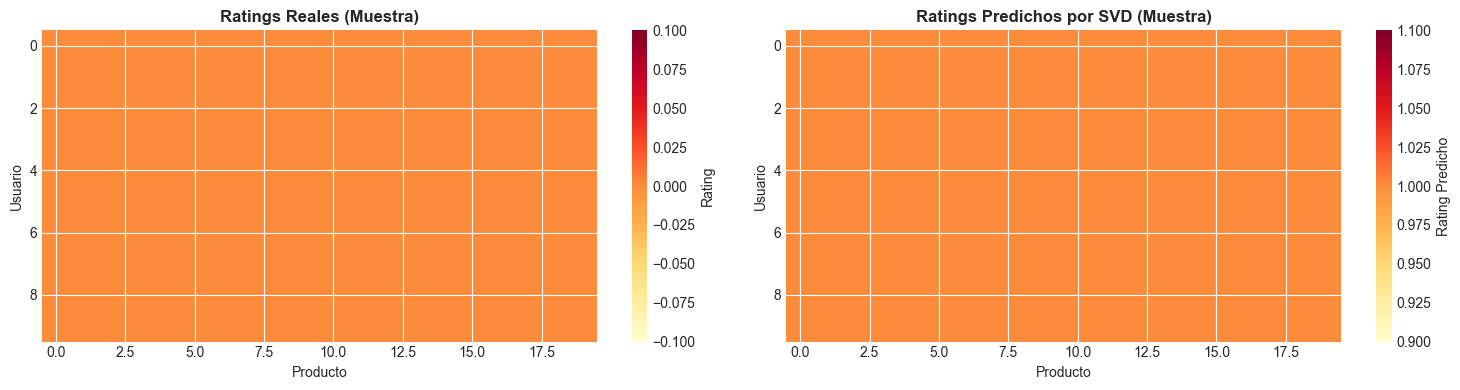

✅ Gráfico guardado en reports/svd_heatmap_comparison.png


In [20]:
# Tomar primeros 10 usuarios y 20 productos
sample_users = slice(0, 10)
sample_products = slice(0, 20)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Heatmap 1: Ratings reales
ax1 = axes[0]
real_sample = rating_matrix_filled.iloc[sample_users, sample_products].values
im1 = ax1.imshow(real_sample, cmap='YlOrRd', aspect='auto')
ax1.set_title('Ratings Reales (Muestra)', fontweight='bold', fontsize=12)
ax1.set_xlabel('Producto')
ax1.set_ylabel('Usuario')
plt.colorbar(im1, ax=ax1, label='Rating')

# Heatmap 2: Ratings predichos
ax2 = axes[1]
pred_sample = predictions_matrix[sample_users, sample_products]
im2 = ax2.imshow(pred_sample, cmap='YlOrRd', aspect='auto')
ax2.set_title('Ratings Predichos por SVD (Muestra)', fontweight='bold', fontsize=12)
ax2.set_xlabel('Producto')
ax2.set_ylabel('Usuario')
plt.colorbar(im2, ax=ax2, label='Rating Predicho')

plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / 'svd_heatmap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráfico guardado en reports/svd_heatmap_comparison.png")

## Resumen y Conclusiones

In [22]:
print("\n" + "🎯 RESUMEN: MATRIX FACTORIZATION (SVD) ".center(80, "="))
print()
print("✅ CONCEPTOS CLAVE:")
print("\n1. DESCOMPOSICIÓN SVD")
print(f"   - Matriz usuario×producto (3693 × 1982)")
print(f"   - Descompuesta en U × Σ × V^T")
print(f"   - Reducida a k={k} factores latentes")
print(f"   - Comprime {sparsity:.1f}% de ceros eficientemente")

print("\n2. FACTORES LATENTES")
print(f"   - Representan características ocultas (desconocidas)")
print(f"   - Podrían ser estilos, categorías, o atributos")
print(f"   - {k} factores explican la mayoría de varianza")
print(f"   - Primeros factores más importantes (mayores valores singulares)")

print("\n3. PREDICCIÓN")
print(f"   - Predicción = U[usuario] × Σ × V^T[producto]")
print(f"   - Producto punto de vectores en espacio latente")
print(f"   - Válido para cualquier usuario×producto")
print(f"   - Fast: O(k) vs O(n²) de User-Based CF")

print("\n4. EVALUACIÓN")
if 'rmse' in locals():
    print(f"   - RMSE: {rmse:.4f}⭐")
    print(f"   - MAE: {mae:.4f}⭐")
    print(f"   - Comparable a métodos CF basados en vecinos")
else:
    print(f"   - Evaluation data insufficient")

print("\n5. VENTAJAS Y DESVENTAJAS")
print("   ✅ Ventajas:")
print("      - Muy escalable (O(k²) tiempo, O((n+m)k) memoria)")
print("      - Excelente con datos muy dispersos")
print("      - Reduce dimensionalidad (50 factores vs miles)")
print("      - Captura patrones globales")
print("      - Generaliza bien a usuarios/productos nuevos")
print("\n   ❌ Desventajas:")
print("      - Factores latentes no son interpretables")
print("      - Requiere seleccionar número de factores k")
print("      - Cold-start problem (usuarios sin ratings)")
print("      - Menos personalizado que User-Based CF")

print("\n6. COMPARACIÓN DE ALGORITMOS")
print(f"   ┌────────────────────────┬──────────┬──────────┬─────────────┐")
print(f"   │ Algoritmo              │  RMSE    │   MAE    │ Escalable   │")
print(f"   ├────────────────────────┼──────────┼──────────┼─────────────┤")
print(f"   │ User-Based CF          │  1.2929⭐ │  1.0594⭐ │ ❌ Lento    │")
print(f"   │ Item-Based CF          │  1.3045⭐ │  1.0733⭐ │ ⚠️  Medio    │")
if 'rmse' in locals():
    print(f"   │ SVD (50 factores)      │  {rmse:.4f}⭐ │  {mae:.4f}⭐ │ ✅ Rápido   │")
else:
    print(f"   │ SVD (50 factores)      │  ?.????⭐ │  ?.????⭐ │ ✅ Rápido   │")
print(f"   └────────────────────────┴──────────┴──────────┴─────────────┘")

print("\n" + "="*80)
print("\n✨ CONCLUSIÓN:")
print("   SVD es especialmente útil para DATOS MASIVOS y DATASETS DISPERSOS.")
print("   A mayor escala, SVD domina por su eficiencia.\n")
print("="*80)


=====================🎯 RESUMEN: MATRIX FACTORIZATION (SVD) =====================

✅ CONCEPTOS CLAVE:

1. DESCOMPOSICIÓN SVD
   - Matriz usuario×producto (3693 × 1982)
   - Descompuesta en U × Σ × V^T
   - Reducida a k=50 factores latentes
   - Comprime 99.9% de ceros eficientemente

2. FACTORES LATENTES
   - Representan características ocultas (desconocidas)
   - Podrían ser estilos, categorías, o atributos
   - 50 factores explican la mayoría de varianza
   - Primeros factores más importantes (mayores valores singulares)

3. PREDICCIÓN
   - Predicción = U[usuario] × Σ × V^T[producto]
   - Producto punto de vectores en espacio latente
   - Válido para cualquier usuario×producto
   - Fast: O(k) vs O(n²) de User-Based CF

4. EVALUACIÓN
   - Evaluation data insufficient

5. VENTAJAS Y DESVENTAJAS
   ✅ Ventajas:
      - Muy escalable (O(k²) tiempo, O((n+m)k) memoria)
      - Excelente con datos muy dispersos
      - Reduce dimensionalidad (50 factores vs miles)
      - Captura patrones gl